In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


# 1. tensorflow v2.xx 에서 v1 사용하기

In [2]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()  # v2를 비활성화하고 v1활성화

Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
import numpy as np
import pandas as pd

## Tensorflow
- 데이터 흐름 그래프
- 이 그래프는 node(상수, 변수, 연산)와 edge로 구성
- sess = tf.Session() 으로 실행
- sess.run()을 통해 값을 확인

In [5]:
# tensor = data(상수, 변수)와 연산
node1 = tf.constant('Hello, Tensoflow')
sess = tf.Session()
print(node1)
print(sess.run(node1))

Tensor("Const_1:0", shape=(), dtype=string)
b'Hello, Tensoflow'


In [7]:
# 간단한 연산 tensor 그래프
node1 = tf.constant(10, dtype=tf.float16)  # node 1에 변수
node2 = tf.constant(20, dtype=tf.float16)

node3 = tf.add(node1, node2)

sess = tf.Session()

print(sess.run([node1, node2]))
print(sess.run(node3))

[10.0, 20.0]
30.0


In [10]:
# 타입 변경
node1 = tf.constant(np.array([1,2,3]), dtype=tf.int16)
node2 = tf.cast(node1, dtype=tf.float32)  # cast 데이터 타입을 바꾸는 함수
sess = tf.Session()
sess.run([node1, node2])

[array([1, 2, 3], dtype=int16), array([1., 2., 3.], dtype=float32)]

In [11]:
# 평균값 계산 : tf.reduce_mean()
data = np.array([1.,2.,3.])
tensor = tf.reduce_mean(data)
sess = tf.Session()
sess.run(tensor)

2.0

In [15]:
# 랜덤 값을 갖는 tensor
a = tf.random_normal([1])
b = tf.random_normal([1])# 평균 0 , 표준편자가 1인 난수 실수 '1'개(정규분포를 이루는 난수)
sess = tf.Session()
sess.run([a,b])

[array([-0.5181857], dtype=float32), array([0.2773121], dtype=float32)]

In [16]:
w = tf.Variable(tf.random.normal([1]))
sess = tf.Session()
sess.run(tf.global_variables_initializer())  # w변수의 난수 초기화
sess.run(w)

array([-1.3505137], dtype=float32)

# 2. tensorflow v1을 이용한 Linear regression
## 2.1 입력(독립)변수 x가 1개, 타겟(종속)변수 y가 1개

In [19]:
x = np.array([1,2,3])
y = np.array([2,3,4])
# weight와 bias(처음엔 랜덤값으로 세팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bais')
# Hypothesis : 예측값
H = W*x +b
# cost function(손실함수 = 'mse';최소제곱법)
cost = tf.reduce_mean(tf.square(H-y))
'''
학습목적 : cost가 최소가 되는 W, b를 찾아내는 것
cost는 2차 함수이므로 곡선 그래프. 곡선 위 미분값이 줄어드는 방향으로 W, b를 학습(경사하강법)
=> GradientDescentOptimizer

'''
optimizer = tf.train.GradientDescentOptimizer(learning_rate=0.01)
train = optimizer.minimize(cost)
# Session 생성
sess = tf.Session()
# W, b 변수 노드에 초기화
sess.run(tf.global_variables_initializer())
# 5000번 학습 (v2에서는 fit 함수)
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b])
    if step%200 ==0:
        print(f'{step}번째 cost : {cost_val}, W: {W_val}, b:{b_val}')

0번째 cost : 4.511729717254639, W: [0.9079076], b:[-0.7181671]
200번째 cost : 0.10875586420297623, W: [1.3820999], b:[0.13139708]
400번째 cost : 0.04152831807732582, W: [1.2361146], b:[0.463256]
600번째 cost : 0.015857519581913948, W: [1.1459044], b:[0.66832507]
800번째 cost : 0.006055161822587252, W: [1.09016], b:[0.7950452]
1000번째 cost : 0.0023121642880141735, W: [1.0557134], b:[0.8733502]
1200번째 cost : 0.0008828918798826635, W: [1.0344274], b:[0.9217384]
1400번째 cost : 0.0003371388593222946, W: [1.0212744], b:[0.9516387]
1600번째 cost : 0.0001287310296902433, W: [1.013146], b:[0.9701161]
1800번째 cost : 4.915614772471599e-05, W: [1.0081234], b:[0.9815335]
2000번째 cost : 1.8770198948914185e-05, W: [1.0050199], b:[0.98858875]
2200번째 cost : 7.1682079578749835e-06, W: [1.0031021], b:[0.9929483]
2400번째 cost : 2.737207751124515e-06, W: [1.001917], b:[0.9956424]
2600번째 cost : 1.0456416248416645e-06, W: [1.0011849], b:[0.99730676]
2800번째 cost : 3.997873818661901e-07, W: [1.0007328], b:[0.9983347]
3000번째 co

In [20]:
# 최종적으로 나온 회귀식 :  H = W*x + b
sess.run([W,b])

[array([1.0000087], dtype=float32), array([0.9999811], dtype=float32)]

In [22]:
W_, b_ = sess.run([W,b])
W_[0], b_[0]

(1.0000087, 0.9999811)

In [23]:
def predict(x):
    return W_[0]*x+b_[0]

In [24]:
input_x = int(input('입력값 : '))
print('예측값은 ', predict(input_x))

입력값 : 3
예측값은  4.000007212162018


## 2.2 predict를 위한 placeholder 이용
- placeholder : 텐서플로우 외부에서 데이터를 입력받는 노드

In [27]:
# x = np.array([1,2,3])
x = tf.placeholder(dtype=tf.float16)
H = 1*x +1
sess = tf.Session()
sess.run(H, feed_dict={x:5})
sess.run(H, feed_dict={x:np.array([1,2,3])})

array([2., 3., 4.], dtype=float16)

In [29]:
# H = 2x+3
x_data = np.array([1,2,3,5, 8])
y_data = np.array([5,7,9,13,19])

# tensor 그래프

# placeholder 설정 (입력변수 x, 타겟변수 y를 나중에)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)
# W, b
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bias')
# Hypothesis(예측값)
H = W*x + b
# 손실함수
cost = tf.reduce_mean(tf.square(H-y))
# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)
# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화
# 5000번 학습
for step in range(5001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={x:x_data, 
                                                                         y:y_data})
    if step%200 ==0:
        print("{}째 : cost : {}, W:{}, b : {}".format(step,
                                                    cost_val,
                                                    W_val,
                                                    b_val))

0째 : cost : 177.49880981445312, W:[0.8230245], b : [0.32953924]
200째 : cost : 0.16684268414974213, W:[2.1389086], b : [2.2575352]
400째 : cost : 0.01641027443110943, W:[2.0435648], b : [2.7671478]
600째 : cost : 0.0016141285886988044, W:[2.013663], b : [2.9269712]
800째 : cost : 0.0001587724545970559, W:[2.004285], b : [2.9770963]
1000째 : cost : 1.5621630154782906e-05, W:[2.0013442], b : [2.9928155]
1200째 : cost : 1.5368528920589597e-06, W:[2.0004218], b : [2.9977462]
1400째 : cost : 1.512413234650012e-07, W:[2.0001323], b : [2.9992929]
1600째 : cost : 1.4966008876626802e-08, W:[2.0000417], b : [2.9997776]
1800째 : cost : 1.4865235709038416e-09, W:[2.000013], b : [2.99993]
2000째 : cost : 1.3569660672896333e-10, W:[2.000004], b : [2.9999788]
2200째 : cost : 1.3569660672896333e-10, W:[2.000004], b : [2.9999788]
2400째 : cost : 1.3569660672896333e-10, W:[2.000004], b : [2.9999788]
2600째 : cost : 1.3569660672896333e-10, W:[2.000004], b : [2.9999788]
2800째 : cost : 1.3569660672896333e-10, W:[2.0000

In [31]:
# 예측하기
sess.run(H, feed_dict={x: np.array([5,6,7])})

array([12.999999, 15.000004, 17.000008], dtype=float32)

## 2.3 scale이 다른 데이터

In [34]:
# H = 2x+3
x_data = np.array([1,2,5, 8, 10])
y_data = np.array([3,15,68,80,95])

# placeholder 설정 (입력변수 x, 타겟변수 y를 나중에)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)

# W, b
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bias')

# Hypothesis(예측값)
H = W*x + b

# 손실함수
cost = tf.reduce_mean(tf.square(H-y))

# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)

# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화

# 5000번 학습
for step in range(2001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={x:x_data, 
                                                                         y:y_data})
    if step%200 ==0:
        print("{}째 : cost : {}, W:{}, b : {}".format(step,
                                                    cost_val,
                                                    W_val,
                                                    b_val))

0째 : cost : 4858.78125, W:[7.700286], b : [0.6507112]
200째 : cost : 83.63560485839844, W:[10.207252], b : [-0.66726744]
400째 : cost : 83.49635314941406, W:[10.273804], b : [-1.1600398]
600째 : cost : 83.48359680175781, W:[10.2939625], b : [-1.3092968]
800째 : cost : 83.4824447631836, W:[10.300068], b : [-1.354506]
1000째 : cost : 83.4823226928711, W:[10.301918], b : [-1.3682002]
1200째 : cost : 83.4823226928711, W:[10.302478], b : [-1.372347]
1400째 : cost : 83.48230743408203, W:[10.302648], b : [-1.3736038]
1600째 : cost : 83.4822998046875, W:[10.302699], b : [-1.3739834]
1800째 : cost : 83.48228454589844, W:[10.302714], b : [-1.374098]
2000째 : cost : 83.48230743408203, W:[10.302718], b : [-1.3741316]


In [35]:
# cost값이 멈춤

## 2.4 scale이 다른 데이터의 linear regression 구현(scale 조정 O)
### 모든 데이터를 일정범위 내로 조정
- normalization(정규화) : 0~1 사이로 조정
    - normalization = (X - Xmin) / (Xmax - Xmin)
        * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.MinMaxScaler)
- standardization(표준화) : 평균 0, 표준편차 1로 조정
    - standardization = ( X - Xmean(평균) ) / Xstd(표준편차)
        * 위의 식을 써도 되지만 라이브러리를 씀(sklearn.preprocessing.StandardScaler)

In [39]:
# 라이브러리를 쓰지 않고 정규화
x_data = np.array([1,2,5, 8, 10])
y_data = np.array([3,15,68,80,95])
scaled_x_data = (x_data - x_data.min()) / (x_data.max() - x_data.min())
scaled_y_data = (y_data - y_data.min()) / (y_data.max() - y_data.min())
scaled_x_data, scaled_y_data

(array([0.        , 0.11111111, 0.44444444, 0.77777778, 1.        ]),
 array([0.        , 0.13043478, 0.70652174, 0.83695652, 1.        ]))

In [48]:
# 라이브러리를 쓰고 정규화(MinMaxScaler)
from sklearn.preprocessing import MinMaxScaler, StandardScaler
x_data = np.array([1,2,5, 8, 10]).reshape(-1,1) # 1차원 -> 2차원으로  축추가 필요
y_data = np.array([3,15,68,80,95]).reshape(-1,1)
# np.column_stack([x_data, y_data])
scaled_x = MinMaxScaler()  # x_data를 정규화시킬 객체
scaled_y = MinMaxScaler()  # y_data를 정규화시킬 객체

# scaled_x.fit(x_data)
# scaled_x_data = scaled_x.transform(x_data)  # 이 2줄을 한줄로 작성
scaled_x_data = scaled_x.fit_transform(x_data)
# print(scaled_x_data)
scaled_y_data = scaled_y.fit_transform(y_data)
# print(scaled_y_data)
np.column_stack([x_data, y_data, scaled_x_data, scaled_y_data]) # 각 배열을 하나의 2차원 배열로 column_stack

array([[ 1.        ,  3.        ,  0.        ,  0.        ],
       [ 2.        , 15.        ,  0.11111111,  0.13043478],
       [ 5.        , 68.        ,  0.44444444,  0.70652174],
       [ 8.        , 80.        ,  0.77777778,  0.83695652],
       [10.        , 95.        ,  1.        ,  1.        ]])

In [54]:
# placeholder 설정 (입력변수 x, 타겟변수 y를 나중에)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)

# W, b
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bias')

# Hypothesis(예측값)
H = W*x + b

# 손실함수
cost = tf.reduce_mean(tf.square(H-y))

# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)

# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화

# 5000번 학습
for step in range(10001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={x:scaled_x_data, 
                                                                         y:scaled_y_data})
    if step%1000 ==0:
        print("{}째 : cost : {}, W:{}, b : {}".format(step,
                                                    cost_val,
                                                    W_val,
                                                    b_val))

0째 : cost : 1.7559852600097656, W:[-0.08149213], b : [1.8245347]
1000째 : cost : 0.25227323174476624, W:[-0.20234491], b : [0.80129194]
2000째 : cost : 0.15618900954723358, W:[0.02055771], b : [0.59397495]
3000째 : cost : 0.10164833068847656, W:[0.22339284], b : [0.47945735]
4000째 : cost : 0.067461296916008, W:[0.38623673], b : [0.39283708]
5000째 : cost : 0.04600806534290314, W:[0.51541483], b : [0.3245566]
6000째 : cost : 0.03254537284374237, W:[0.6177611], b : [0.2704947]
7000째 : cost : 0.024097073823213577, W:[0.6988379], b : [0.22767058]
8000째 : cost : 0.018795449286699295, W:[0.7630648], b : [0.19374666]
9000째 : cost : 0.015468502417206764, W:[0.8139435], b : [0.16687316]
10000째 : cost : 0.013380734249949455, W:[0.85424805], b : [0.14558475]


In [64]:
# 예측 : 모델에 scale 조정된 값으로 예측 -> 스케일 조정된 y 값 -> 스케일 전 y 값으로 반환
scaled_input = scaled_x.transform(np.array([[2],
                                          [3]]))
print('모델예측을 위한 입력 : ', scaled_input, sep='\n')
scaled_output = sess.run(H, feed_dict={x:scaled_input})
print('모델예측결과 : ', scaled_output, sep='\n')
print('결과 : ', scaled_y.inverse_transform(scaled_output), sep='n' )


모델예측을 위한 입력 : 
[[0.11111111]
 [0.22222222]]
모델예측결과 : 
[[0.2405012 ]
 [0.33541763]]
결과 : n[[25.12611]
 [33.85842]]


In [68]:
# x_data 들의 예측 값
scaled_y_hat = sess.run(H, feed_dict={x : scaled_x_data})
y_hat = scaled_y.inverse_transform(scaled_y_hat)
y_hat

array([[16.393797],
       [25.12611 ],
       [51.32305 ],
       [77.52    ],
       [94.98462 ]], dtype=float32)

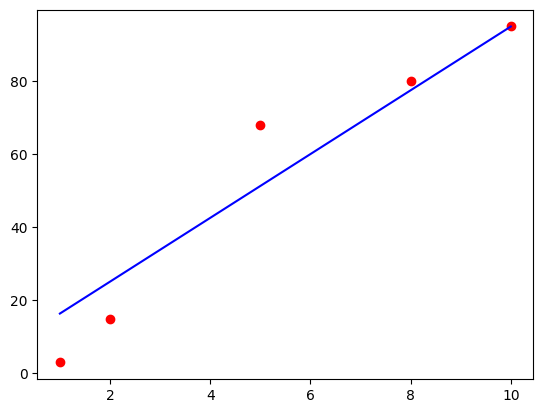

In [73]:
import matplotlib.pyplot as plt
plt.plot(x_data, y_data, 'o', c='r')
plt.plot(x_data, y_hat, 'b')

In [77]:
# 라이브러리를 쓰고 표준화 (StandardScaler)

x_data = np.array([1,2,5, 8, 10]).reshape(-1,1) # 1차원 -> 2차원으로  축추가 필요
y_data = np.array([3,15,68,80,95]).reshape(-1,1)

scaler_x = StandardScaler()  # x_data를 정규화시킬 객체
scaler_y = StandardScaler()  # y_data를 정규화시킬 객체

scaled_x_data = scaler_x.fit_transform(x_data)
scaled_y_data = scaler_y.fit_transform(y_data)
print(np.column_stack([x_data, y_data]))
print(np.column_stack([scaled_x_data, scaled_y_data]))

[[ 1  3]
 [ 2 15]
 [ 5 68]
 [ 8 80]
 [10 95]]
[[-1.22474487 -1.34819316]
 [-0.93313895 -1.01936556]
 [-0.05832118  0.43295634]
 [ 0.81649658  0.76178394]
 [ 1.39970842  1.17281844]]


In [78]:
# placeholder 설정 (입력변수 x, 타겟변수 y를 나중에)
x = tf.placeholder(dtype=tf.float32)
y = tf.placeholder(dtype=tf.float32)

# W, b
W = tf.Variable(tf.random.normal([1]), name = 'weight')
b = tf.Variable(tf.random.normal([1]), name = 'bias')

# Hypothesis(예측값)
H = W*x + b

# 손실함수
cost = tf.reduce_mean(tf.square(H-y))

# 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.001).minimize(cost)

# 세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화

# 5000번 학습
for step in range(10001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={x:scaled_x_data, 
                                                                         y:scaled_y_data})
    if step%1000 ==0:
        print("{}째 : cost : {}, W:{}, b : {}".format(step,
                                                    cost_val,
                                                    W_val,
                                                    b_val))

0째 : cost : 3.98213529586792, W:[-0.23423612], b : [1.5678186]
1000째 : cost : 0.13418591022491455, W:[0.80575025], b : [0.21175657]
2000째 : cost : 0.0639900416135788, W:[0.94621545], b : [0.02860082]
3000째 : cost : 0.0627094954252243, W:[0.9651872], b : [0.00386297]
4000째 : cost : 0.06268613785505295, W:[0.96774983], b : [0.00052176]
5000째 : cost : 0.06268570572137833, W:[0.96809494], b : [7.048197e-05]
6000째 : cost : 0.06268569082021713, W:[0.96813506], b : [9.538892e-06]
7000째 : cost : 0.06268569082021713, W:[0.96813506], b : [1.3118866e-06]
8000째 : cost : 0.06268569827079773, W:[0.96813506], b : [2.016292e-07]
9000째 : cost : 0.06268568336963654, W:[0.96813506], b : [5.5716278e-08]
10000째 : cost : 0.06268568336963654, W:[0.96813506], b : [4.0816197e-08]


In [80]:
# x_data 들의 예측 값
scaled_y_hat = sess.run(H, feed_dict={x : scaled_x_data})
y_hat = scaler_y.inverse_transform(scaled_y_hat)
y_hat

array([[  8.929233],
       [ 19.2318  ],
       [ 50.13949 ],
       [ 81.04718 ],
       [101.6523  ]], dtype=float32)

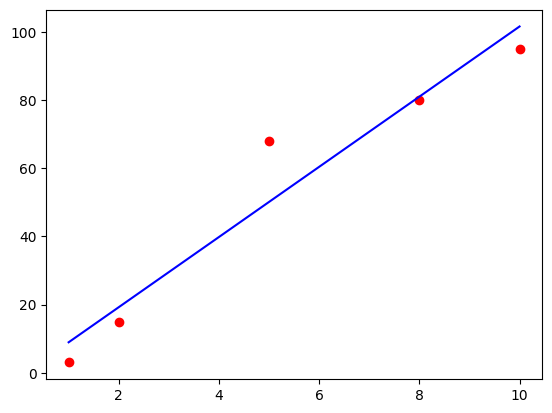

In [81]:
plt.plot(x_data, y_data, 'o', c='r')
plt.plot(x_data, y_hat, 'b')

## 2.5 입력(독립)변수 x가 3개, 타겟(종속)변수 y가 1개(csv->array)

In [8]:
# 방법1 : csv -> array
# data = np.loadtxt('data/ozone.csv', delimiter = ',') # 결측치, 헤더가 없어야함.
# 위 파일은 결측치와 헤더가 있어 오류가 발생
# data = np.loadtxt('data/pima-indians-diabetes.csv', delimiter = ',', encoding='utf-8')
data = np.genfromtxt('data/ozone.csv', 
                     delimiter = ',',
                    skip_header=1,         # 헤더 스킵
                    missing_values='NA',   # 결측치 정의
                    filling_values=np.nan  # 결측치는 np.nan으로 채워라
                    )
data[:5] 
# 방법 1은 결측치가 있기 때문에 비추천. array에서 결측치 처리하기란 난이도가 너무 높기 때문이다

array([[ 41. , 190. ,   7.4,  67. ,   5. ,   1. ],
       [ 36. , 118. ,   8. ,  72. ,   5. ,   2. ],
       [ 12. , 149. ,  12.6,  74. ,   5. ,   3. ],
       [ 18. , 313. ,  11.5,  62. ,   5. ,   4. ],
       [  nan,   nan,  14.3,  56. ,   5. ,   5. ]])

In [11]:
# 방법2 : csv파일 -> 데이터프레인 -> 결측치 처리 -> 넘파이배열 -> 머신러닝
# 1.csv를 데이터프레임으로 읽기
df = pd.read_csv('data/ozone.csv')
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5


In [13]:
df.info()  # 결측치는 오존과 솔라에만 있는 걸 확인
df.isna().sum() # 열별 결측지 갯수

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [23]:
# 2. 결측치 처리
# 2-1. 결측치가 있는 행을 제거
# df.dropna(how='any', axis=0).shape # 111행만 남음. 너무 데이터가 적어지는 문제 발생
# 2-2. 결측치 대체 - 열별 평균값으로 대체
df.mean(axis=0) # 열별평균
# df.fillna(value=df.mean(), inplace=True)
# 2-3. 결측치 대체 - 월별 열별 평균값으로 대체
mean_data = df.groupby(by='Month')[['Ozone', 'Solar.R']].mean()
display(mean_data)
print('5월에 Ozone으로 대체할 값 : ', mean_data.loc[5,'Ozone'])

,Ozone,Solar.R
Month,,
5,23.615385,181.296296
6,29.444444,190.166667
7,59.115385,216.483871
8,59.961538,171.857143
9,31.448276,167.433333


5월에 Ozone으로 대체할 값 :  23.615384615384617


In [27]:
def fill_nan(row):
    # row = row.copy()
    pd.options.mode.copy_on_write = True
    if row.isna()['Ozone']:
        row['Ozone'] = mean_data.loc[row.Month, 'Ozone']
    if row.isna()['Solar.R']:
        row['Solar.R'] = mean_data.loc[row.Month, 'Solar.R']
    return row
fill_nan(df.loc[4])

Ozone       23.615385
Solar.R    181.296296
Wind        14.300000
Temp        56.000000
Month        5.000000
Day          5.000000
Name: 4, dtype: float64

In [29]:
df = df.apply(fill_nan, axis=1)

In [36]:
X_data = df[['Solar.R', 'Wind', 'Temp']].values
y_data = df[['Ozone']].values
X_data.shape, y_data.shape

((153, 3), (153, 1))

In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaled_X_data = scaler_X.fit_transform(X_data)
scaled_y_data = scaler_y.fit_transform(y_data)

scaled_X_data

array([[0.55963303, 0.3       , 0.26829268],
       [0.33944954, 0.33157895, 0.3902439 ],
       [0.43425076, 0.57368421, 0.43902439],
       [0.93577982, 0.51578947, 0.14634146],
       [0.5330162 , 0.66315789, 0.        ],
       [0.5330162 , 0.69473684, 0.24390244],
       [0.89296636, 0.36315789, 0.2195122 ],
       [0.28134557, 0.63684211, 0.07317073],
       [0.03669725, 0.96842105, 0.12195122],
       [0.57186544, 0.36315789, 0.31707317],
       [0.5330162 , 0.27368421, 0.43902439],
       [0.76146789, 0.42105263, 0.31707317],
       [0.86544343, 0.39473684, 0.24390244],
       [0.81651376, 0.48421053, 0.29268293],
       [0.17737003, 0.60526316, 0.04878049],
       [1.        , 0.51578947, 0.19512195],
       [0.91743119, 0.54210526, 0.24390244],
       [0.21712538, 0.87894737, 0.02439024],
       [0.96330275, 0.51578947, 0.29268293],
       [0.11314985, 0.42105263, 0.14634146],
       [0.0030581 , 0.42105263, 0.07317073],
       [0.95718654, 0.78421053, 0.41463415],
       [0.

### tensorflow 구현

In [88]:
# 1. X, y tensor 생성 - placeholder 이용
X = tf.placeholder(shape=[None, 3], dtype='float32')
y = tf.placeholder(shape=[None, 1], dtype='float32')

# 2. 독립변수 3개, 타겟변수 1개인 모델의 weight와 bias(처음엔 랜덤값으로 세팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([3, 1]), name = 'weight')  # 앞의 3은 입력변수 개수, 뒤의 1은 타겟변수 개수가 됨. 행열로 계산하기 위해
b = tf.Variable(tf.random.normal([1]), name = 'bais')

# 3. 예측값 계산
# H = X@W +b
H = tf.matmul(X, W) + b  # tf.matmul :행렬연산을 해주는 함수

# 4. cost(손실) 함수 : mse
cost = tf.reduce_mean(tf.square(H-y))

# 5. train : 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=1e-5).minimize(cost)

# 6. 세션객체 생성 및 초기화
sess = tf.Session()
sess.run(tf.global_variables_initializer())

# 일반 데이터로 학습

for step in range(1, 100001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={X:X_data, y:y_data} )
    #_, cost_val = sess.run([train, cost], feed_dict={X:X_data, y:y_data} )
    W1_val, W2_val, W3_val = W_val.reshape(-1)
    if step%2000 == 0:
        print("{}째 : cost : {}, W1:{}, W2:{}, W3:{}, b : {}".format(step,
                                                    cost_val,
                                                    W1_val, W2_val, W3_val,
                                                    b_val))

2000째 : cost : 531.3535766601562, W1:0.051260847598314285, W2:-1.576549768447876, W3:0.6306717395782471, b : [-0.99540484]
4000째 : cost : 478.95245361328125, W1:0.05328620225191116, W2:-2.572667360305786, W3:0.7496994733810425, b : [-1.0318601]
6000째 : cost : 465.7730407714844, W1:0.054300788789987564, W2:-3.0718090534210205, W3:0.8094605803489685, b : [-1.0593755]
8000째 : cost : 462.44879150390625, W1:0.05480879172682762, W2:-3.3218281269073486, W3:0.839512288570404, b : [-1.0824068]
10000째 : cost : 461.60064697265625, W1:0.0550629198551178, W2:-3.446977376937866, W3:0.8546724915504456, b : [-1.1031876]
12000째 : cost : 461.3746032714844, W1:0.05518977716565132, W2:-3.5095314979553223, W3:0.8623676896095276, b : [-1.1228336]
14000째 : cost : 461.3050842285156, W1:0.05525267869234085, W2:-3.5407090187072754, W3:0.8663215041160583, b : [-1.1419162]
16000째 : cost : 461.274658203125, W1:0.055283620953559875, W2:-3.5561599731445312, W3:0.8683999180793762, b : [-1.1607271]
18000째 : cost : 461

In [60]:
np.column_stack([X_data, y_data])[:3]

array([[190. ,   7.4,  67. ,  41. ],
       [118. ,   8. ,  72. ,  36. ],
       [149. ,  12.6,  74. ,  12. ]])

In [92]:
# 예측하기
input_data = np.array([[149, 12.6, 74]]) 
sess.run(H, feed_dict={X:input_data})

array([[26.479097]], dtype=float32)

### 스케일 정규화 
- MinMaxScaler : 0~1 사이
- Standardizaion : -2~2 사이, 주로 0 근처

In [63]:
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaled_X_data = scaler_X.fit_transform(X_data)
scaled_y_data = scaler_y.fit_transform(y_data)

scaled_X_data

array([[0.55963303, 0.3       , 0.26829268],
       [0.33944954, 0.33157895, 0.3902439 ],
       [0.43425076, 0.57368421, 0.43902439],
       [0.93577982, 0.51578947, 0.14634146],
       [0.5330162 , 0.66315789, 0.        ],
       [0.5330162 , 0.69473684, 0.24390244],
       [0.89296636, 0.36315789, 0.2195122 ],
       [0.28134557, 0.63684211, 0.07317073],
       [0.03669725, 0.96842105, 0.12195122],
       [0.57186544, 0.36315789, 0.31707317],
       [0.5330162 , 0.27368421, 0.43902439],
       [0.76146789, 0.42105263, 0.31707317],
       [0.86544343, 0.39473684, 0.24390244],
       [0.81651376, 0.48421053, 0.29268293],
       [0.17737003, 0.60526316, 0.04878049],
       [1.        , 0.51578947, 0.19512195],
       [0.91743119, 0.54210526, 0.24390244],
       [0.21712538, 0.87894737, 0.02439024],
       [0.96330275, 0.51578947, 0.29268293],
       [0.11314985, 0.42105263, 0.14634146],
       [0.0030581 , 0.42105263, 0.07317073],
       [0.95718654, 0.78421053, 0.41463415],
       [0.

In [94]:
# 1. X, y tensor 생성 - placeholder 이용
X = tf.placeholder(shape=[None, 3], dtype='float32')
y = tf.placeholder(shape=[None, 1], dtype='float32')

# 2. 독립변수 3개, 타겟변수 1개인 모델의 weight와 bias(처음엔 랜덤값으로 세팅, 학습과정에서 변경)
W = tf.Variable(tf.random.normal([3, 1]), name = 'weight')  # 앞의 3은 입력변수 개수, 뒤의 1은 타겟변수 개수가 됨. 행열로 계산하기 위해
b = tf.Variable(tf.random.normal([1]), name = 'bais')

# 3. 예측값 계산
# H = X@W +b
H = tf.matmul(X, W) + b  # tf.matmul :행렬연산을 해주는 함수

# 4. cost(손실) 함수 : mse
cost = tf.reduce_mean(tf.square(H-y))

# 5. train : 경사하강법
train = tf.train.GradientDescentOptimizer(learning_rate=0.00001).minimize(cost)

# 6. 세션객체 생성 및 초기화
sess = tf.Session()
sess.run(tf.global_variables_initializer())

# 7. 정규화 데이터 로 학습
for step in range(1, 100001):
    _, cost_val, W_val, b_val = sess.run([train, cost, W, b], feed_dict={X:scaled_X_data, y:scaled_y_data} )
    W1_val, W2_val, W3_val = W_val.reshape(-1)
    if step%10000 == 0:
        print("{}째 : cost : {}, W1:{}, W2:{}, W3:{}, b : {}".format(step,
                                                    cost_val,
                                                    W1_val, W2_val, W3_val,
                                                    b_val))

10000째 : cost : 0.1673557162284851, W1:-0.24020878970623016, W2:1.6382458209991455, W3:0.24158895015716553, b : [-0.41424897]
20000째 : cost : 0.16292770206928253, W1:-0.2392893135547638, W2:1.6202192306518555, W3:0.24613474309444427, b : [-0.42407438]
30000째 : cost : 0.15921105444431305, W1:-0.23706869781017303, W2:1.603529930114746, W3:0.2518724203109741, b : [-0.431424]
40000째 : cost : 0.15588496625423431, W1:-0.23395957052707672, W2:1.5878387689590454, W3:0.2584117650985718, b : [-0.43702933]
50000째 : cost : 0.1527174860239029, W1:-0.23025940358638763, W2:1.5723931789398193, W3:0.265453964471817, b : [-0.4413835]
60000째 : cost : 0.149786114692688, W1:-0.22616735100746155, W2:1.5580880641937256, W3:0.2728455066680908, b : [-0.44488537]
70000째 : cost : 0.1469094604253769, W1:-0.2218216061592102, W2:1.5437829494476318, W3:0.28034308552742004, b : [-0.44774702]
80000째 : cost : 0.1440647840499878, W1:-0.21733006834983826, W2:1.529477834701538, W3:0.2880916893482208, b : [-0.45015794]
900

In [93]:
# 예측하기
input_data = np.array([[190., 7.4, 67.]]) # 
scaled_y_hat = sess.run(H, feed_dict={X:scaler_X.transform(input_data)})
scaler_y.inverse_transform(scaled_y_hat)

array([[-455.51166]], dtype=float32)

In [78]:
sess.run(H, feed_dict={X:input_data})

array([[101.468285]], dtype=float32)

# 3. tensorflow v1을 이용한 분류분석(이진분류=logistic regression)
- logistic regression : 기존의 회귀분석과는 다른 처리 필요


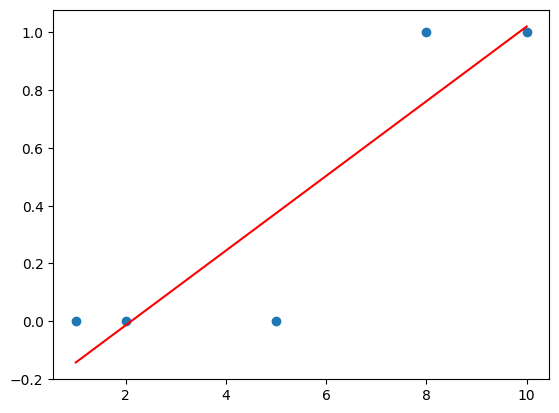

In [98]:
x = np.array([1,2,5,8,10])
y = np.array([0,0,0,1,1]) # 실제값

from scipy import stats
lm = stats.linregress(x, y) # 기울기 W와 y절편(b) 가져옴
H = lm[0]*x + lm[1]
import matplotlib.pyplot as plt
plt.plot(x,H, 'r')
plt.scatter(x, y)

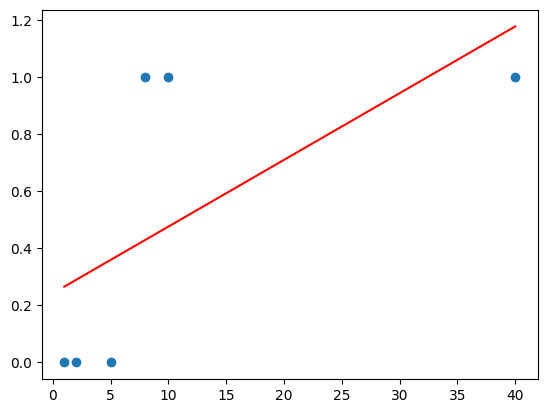

In [99]:
x = np.array([1, 2, 5, 8, 10, 40])
y = np.array([0, 0, 0, 1, 1, 1]) # 실제값

from scipy import stats
lm = stats.linregress(x, y) # 기울기 W와 y절편(b) 가져옴
H = lm[0]*x + lm[1]
import matplotlib.pyplot as plt
plt.plot(x,H, 'r')
plt.scatter(x, y)

In [106]:
# 교안 50p
X_data = np.array([[10, 0],
                 [8,1],
                 [3,3],
                 [2,3],
                 [5,1],
                 [2,0],
                 [1,0]])
y_data = np.array([[1],[1],[1],[1],[0],[0],[0]])
# tensorflow 구현
X = tf.placeholder(shape=[None, 2], dtype=tf.float32)
y = tf.placeholder(shape=[None, 1], dtype=tf.float32)

# 독립변수가 2개, 종속변수 1개의 W, b
W = tf.Variable(tf.random.normal([2, 1]))
b = tf.Variable(tf.random.normal([1]))

# 예측치
logits = tf.matmul(X, W) + b # 이렇게만 하면 단순 회귀 직선만 도출되므로 활성화 함수를 씌운다
H = tf.sigmoid(logits)

# cost 함수
# cost = tf.reduce_mean(tf.square(H-y))
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))

# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.1).minimize(cost)

#세션 객체 생성
sess = tf.Session()
sess.run(tf.global_variables_initializer()) # W, b 초기화

for step in range(10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data, 
                                                                 y:y_data})
    if step%2000 ==0:
        print("{}째 : cost : {}".format(step, cost_val))

0째 : cost : 1.0860481262207031
2000째 : cost : 0.1523476392030716
4000째 : cost : 0.10718514025211334
6000째 : cost : 0.08203224092721939
8000째 : cost : 0.06602407246828079
10000째 : cost : 0.05504606291651726


In [108]:
# 모델 사용
input_data = np.array([[10,0]])
predict = tf.cast(H>=0.5, dtype=tf.float32)
sess.run(predict, feed_dict={X:input_data})

array([[1.]], dtype=float32)

### 분류성능평가지표
<img src="https://velog.velcdn.com/images/leehb9360/post/7eb8ca12-94be-40ed-b7a4-b9e9701a93df/image.png" 
     width="400" style="float: left;">

In [117]:
# accuracy
correct = tf.equal(predict, y)
correct1 = sess.run(correct, feed_dict={X:X_data,
                            y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct1, dtype=tf.float32))
print('모델정확도 : ', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델정확도 :  1.0


# 4. XOR

In [119]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0], [1], [1], [0]])

X = tf.placeholder(shape=[None, 2], dtype= tf.float32)
y = tf.placeholder(shape=[None, 1], dtype= tf.float32)

W = tf.Variable(tf.random.normal([2,1]))
b = tf.Variable(tf.random.normal([1]))

# H
logits = tf.matmul(X, W) + b
H = tf.sigmoid(logits)

# cost

cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
# train

train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)

sess = tf.Session()
sess.run(tf.global_variables_initializer())

for step in range(1,10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data,
                                                    y:y_data})
    if step%1000==0:
        print(f'{step}번째 cost : {cost_val}')

1000번째 cost : 0.6954155564308167
2000번째 cost : 0.6937998533248901
3000번째 cost : 0.6933366656303406
4000번째 cost : 0.693202555179596
5000번째 cost : 0.6931635737419128
6000번째 cost : 0.6931520700454712
7000번째 cost : 0.693148672580719
8000번째 cost : 0.6931476593017578
9000번째 cost : 0.6931473016738892
10000번째 cost : 0.6931472420692444


In [120]:
# accuracy
predict = tf.cast(H>=0.5, dtype=tf.float32)
correct = tf.equal(predict, y)
correct1 = sess.run(correct, feed_dict={X:X_data,
                            y:y_data})
accuracy = tf.reduce_mean(tf.cast(correct1, dtype=tf.float32))
print('모델정확도 : ', sess.run(accuracy, feed_dict={X:X_data, y:y_data}))

모델정확도 :  0.5


# 5. Deep Learning XOR 예제

In [ ]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0], [1], [1], [0]])

X = tf.placeholder(shape=[None, 2], dtype= tf.float32)
y = tf.placeholder(shape=[None, 1], dtype= tf.float32)

# layer1 : (입력2, 출력4)
W1 = tf.Variable(tf.random.normal([2,4]))
b1 = tf.Variable(tf.random.normal([4]))

# H
# temp = tf.matmul(X, W) + b
layer1 = tf.nn.relu( tf.matmul(X, W1) + b1 )  # relu는 특정 값 이상 만 내보내는 역할을 해준다

# layer2 : (입력4, 출력1)
W2 = tf.Variable(tf.random.normal([4,1]))
b2 = tf.Variable(tf.random.normal([1]))
# H
logits = tf.matmul(layer1, W2) + b2
H = tf.sigmoid(logits)

# cost
cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
# train
train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)

# 세션 객체생성
sess = tf.Session()
sess.run(tf.global_variables_initializer())

for step in range(1,10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data,
                                                    y:y_data})
    if step%1000==0:
        print(f'{step}번째 cost : {cost_val}')

In [123]:
# accuracy
predict = tf.cast(H>=0.5, dtype=tf.float32)
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data,
                            y:y_data})
accuracy = tf.reduce_mean( tf.cast(correct, dtype=tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data,
                                               y:y_data}))

모델 정확도 : 1.0


## layer층 x_data 2개 -> 4 -> 1을
## layer층 x_data 2개 -> 10 -> 20 -> 10 -> 1
                                    입력층  hidden layer(relu) 출력층(sigmoid)

In [124]:
X_data = np.array([[0,0],
                  [0,1],
                  [1,0],
                  [1,1]])
y_data = np.array([[0], [1], [1], [0]])

X = tf.placeholder(shape=[None, 2], dtype= tf.float32)
y = tf.placeholder(shape=[None, 1], dtype= tf.float32)

# layer1 : (입력2, 출력10)
W1 = tf.Variable(tf.random.normal([2,10]))
b1 = tf.Variable(tf.random.normal([10]))

# H
# temp = tf.matmul(X, W) + b
layer1 = tf.nn.relu( tf.matmul(X, W1) + b1 )  # relu는 특정 값 이상 만 내보내는 역할을 해준다

# layer2 : (입력10, 출력20)
W2 = tf.Variable(tf.random.normal([10,20]))
b2 = tf.Variable(tf.random.normal([20]))

layer2 = tf.nn.relu( tf.matmul(layer1, W2) + b2 )

# layer3 : (입력20, 출력10)
W3 = tf.Variable(tf.random.normal([20,10]))
b3 = tf.Variable(tf.random.normal([10]))

layer3 = tf.nn.relu( tf.matmul(layer2, W3) + b3 )

# layer4(출력층) : (입력10, 출력1)
W4 = tf.Variable(tf.random.normal([10,1]))
b4 = tf.Variable(tf.random.normal([1]))


logits = tf.matmul(layer3, W4) + b4
H = tf.sigmoid(logits)


# cost

cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=logits,
                                                             labels=y))
# train

train = tf.train.GradientDescentOptimizer(learning_rate=0.01).minimize(cost)

sess = tf.Session()
sess.run(tf.global_variables_initializer())

for step in range(1,10001):
    _, cost_val = sess.run([train, cost], feed_dict={X:X_data,
                                                    y:y_data})
    if step%1000==0:
        print(f'{step}번째 cost : {cost_val}')

1000번째 cost : 0.005039014853537083
2000번째 cost : 0.0020886810962110758
3000번째 cost : 0.0012549246894195676
4000번째 cost : 0.0008772648870944977
5000번째 cost : 0.0006659200880676508
6000번째 cost : 0.0005323823424987495
7000번째 cost : 0.0004409671819303185
8000번째 cost : 0.0003748448798432946
9000번째 cost : 0.0003249670844525099
10000번째 cost : 0.00028610939625650644


In [125]:
# accuracy
predict = tf.cast(H>=0.5, dtype=tf.float32)
correct = tf.equal(predict, y)
sess.run(correct, feed_dict={X:X_data,
                            y:y_data})
accuracy = tf.reduce_mean( tf.cast(correct, dtype=tf.float32))
print('모델 정확도 :', sess.run(accuracy, feed_dict={X:X_data,
                                               y:y_data}))

모델 정확도 : 1.0
